In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
df = pd.read_csv("health_risk_classification.csv")

In [3]:
df.head() #scaled data

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [6]:
df.describe()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.023702,0.016769,-0.020771,0.498000
std,1.203694,1.268761,1.392738,0.500246
min,-4.743951,-2.587178,-4.999018,0.000000
25%,-0.796655,-0.981320,-1.057938,0.000000
50%,0.142105,-0.317137,0.204506,0.000000
75%,0.956225,1.017388,1.061181,1.000000
max,2.321480,3.954873,3.477210,1.000000


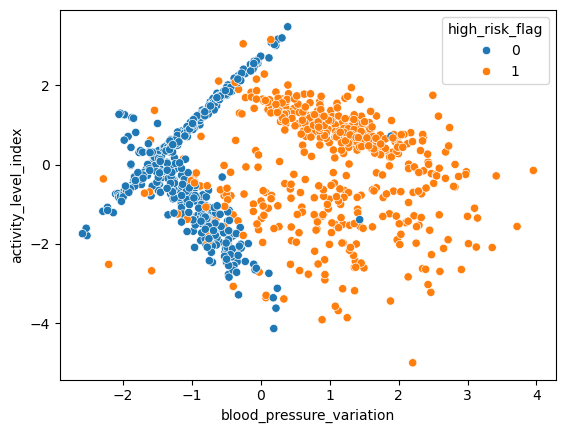

In [7]:
sns.scatterplot(x = df['blood_pressure_variation'], y = df['activity_level_index'], hue = df['high_risk_flag'])
plt.show()

In [8]:
df['high_risk_flag'].value_counts() #balanced

high_risk_flag
0    502
1    498
Name: count, dtype: int64

In [9]:
X = df.drop("high_risk_flag", axis=1)
y = df['high_risk_flag']

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

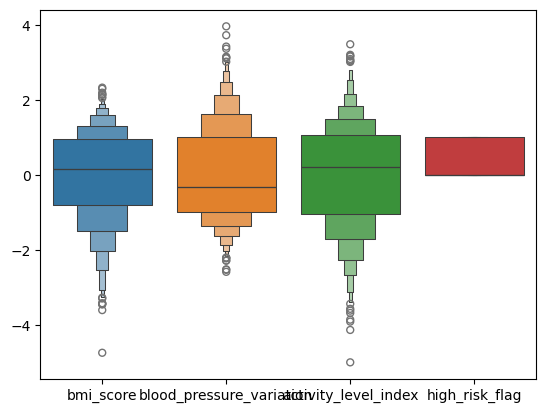

In [12]:
sns.boxenplot(df)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
classifier = KNeighborsClassifier(n_neighbors=5, algorithm='auto',weights="uniform",n_jobs=-1) 

In [16]:
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_jobs=-1)

In [17]:
y_pred = classifier.predict(X_test_scaled)

In [18]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [19]:
print("Score:",accuracy_score(y_pred,y_test))
print("Confusion Matrix: \n",confusion_matrix(y_pred,y_test), "\n")
print("Classification Report: \n",classification_report(y_pred,y_test))

Score: 0.952
Confusion Matrix: 
 [[124  10]
 [  2 114]] 

Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [20]:
classifier = KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree',weights="uniform",n_jobs=-1) 
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier(algorithm='kd_tree', n_jobs=-1)

In [21]:
y_pred = classifier.predict(X_test_scaled)
print("Score:",accuracy_score(y_pred,y_test))
print("Confusion Matrix: \n",confusion_matrix(y_pred,y_test), "\n")
print("Classification Report: \n",classification_report(y_pred,y_test))

Score: 0.952
Confusion Matrix: 
 [[124  10]
 [  2 114]] 

Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [22]:
classifier = KNeighborsClassifier(n_neighbors=3, algorithm='kd_tree',weights="uniform",n_jobs=-1)  #K NUMBER 3 OLDU 
classifier.fit(X_train_scaled,y_train)
y_pred = classifier.predict(X_test_scaled)
print("Score:",accuracy_score(y_pred,y_test))
print("Confusion Matrix: \n",confusion_matrix(y_pred,y_test), "\n")
print("Classification Report: \n",classification_report(y_pred,y_test))

Score: 0.96
Confusion Matrix: 
 [[125   9]
 [  1 115]] 

Classification Report: 
               precision    recall  f1-score   support

           0       0.99      0.93      0.96       134
           1       0.93      0.99      0.96       116

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



In [ ]:
df_reg = pd.read_csv("house_energy_regression.csv")

In [24]:
df_reg.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


In [25]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [26]:
df_reg.describe()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
count,1000.000000,1000.000000,1000.000000
mean,0.033186,0.056982,1.766025
std,0.961603,1.014959,41.299085
min,-3.241267,-2.940389,-132.797922
25%,-0.611581,-0.651418,-25.600072
50%,0.036043,0.047742,1.065474
75%,0.648317,0.714886,28.766573
max,3.078881,3.852731,138.577662


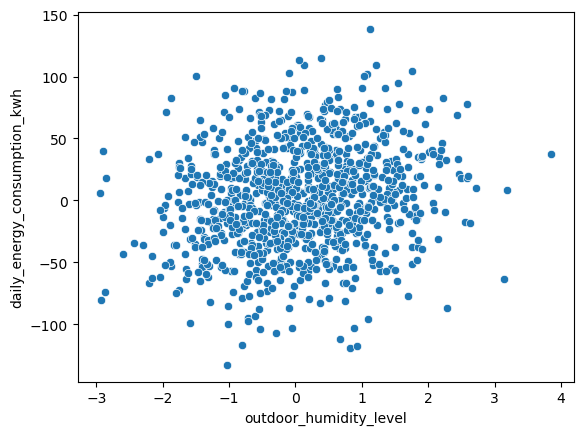

In [27]:
sns.scatterplot(x= df_reg['outdoor_humidity_level'], y = df_reg['daily_energy_consumption_kwh'])
plt.show()

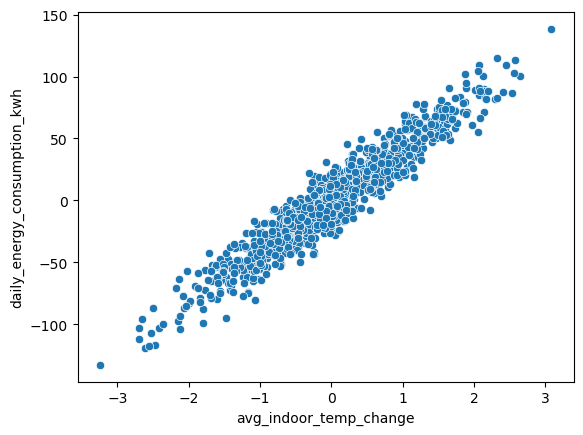

In [28]:
sns.scatterplot(x= df_reg['avg_indoor_temp_change'], y = df_reg['daily_energy_consumption_kwh'])
plt.show()

In [29]:
df_reg.corr()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
avg_indoor_temp_change,1.000000,0.002584,0.956682
outdoor_humidity_level,0.002584,1.000000,0.169557
daily_energy_consumption_kwh,0.956682,0.169557,1.000000


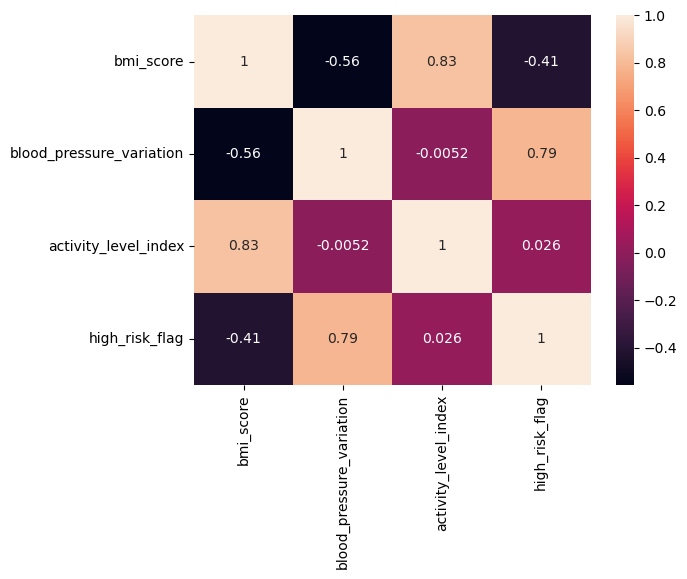

In [30]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [31]:
X = df_reg.drop("daily_energy_consumption_kwh",axis=1)
y = df_reg['daily_energy_consumption_kwh']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
from sklearn.neighbors import KNeighborsRegressor

In [35]:
regressor = KNeighborsRegressor(n_neighbors=5, algorithm='auto')
# KNeighborsRegressor(n_neighbors=5, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None,)

In [36]:
regressor.fit(X_train_scaled,y_train)

KNeighborsRegressor()

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

R2 Score: 0.9183109118983248
Mean Absolute Error:  9.228754406902722
Mean Squared Error:  135.6610827281179


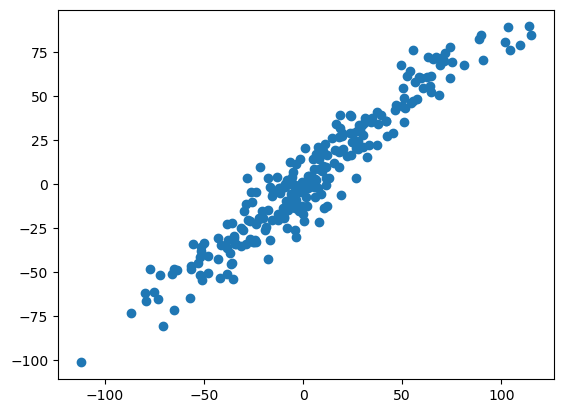

In [38]:
y_pred = regressor.predict(X_test_scaled)
print("R2 Score:",r2_score(y_test,y_pred))
print("Mean Absolute Error: ",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error: ",mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
plt.show()

R2 Score: 0.9189374253850693
Mean Absolute Error:  9.326118628600977
Mean Squared Error:  134.62063167240598


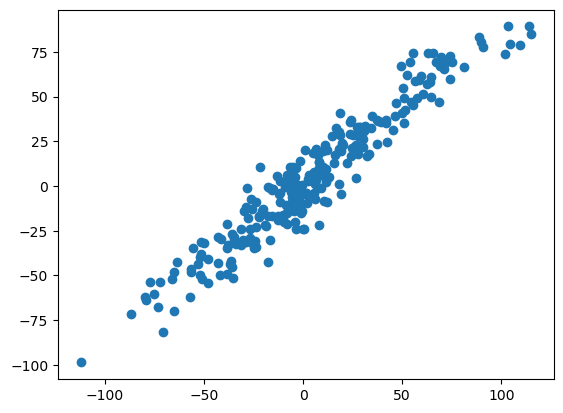

In [39]:
regressor = KNeighborsRegressor(n_neighbors=7, algorithm='auto') # K = 7
regressor.fit(X_train_scaled,y_train)
y_pred = regressor.predict(X_test_scaled)
print("R2 Score:",r2_score(y_test,y_pred))
print("Mean Absolute Error: ",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error: ",mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
plt.show()